In [29]:
'Desarrollo de Tarea 1'

'Desarrollo de Tarea 1'

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats

In [7]:
# Extracción de datos utilizando yfinance
def descargar_datos_yf(tickers, start, end):
    data = yf.download(tickers, start=periodo[0], end=periodo[1], progress=False)
    return data

tickers = ['AAPL', 'JPM', 'TSLA']
periodo = ('2021-01-01', '2024-01-01')

df = descargar_datos_yf(tickers, periodo[0], periodo[1])['Close']
df.head()

Ticker,AAPL,JPM,TSLA
2021-01-04,125.740837,109.491585,243.256668
2021-01-05,127.295494,110.087334,245.036667
2021-01-06,123.010521,115.256592,251.993332
2021-01-07,127.208054,119.041504,272.013336
2021-01-08,128.305954,119.172951,293.339996


In [8]:
#Cálculos de retornos del DataFrame
def calcula_retornos(df):
    retornos = df.pct_change().dropna()
    return retornos

df_retornos = calcula_retornos(df)
df_retornos.head()

Ticker,AAPL,JPM,TSLA
2021-01-05,0.012364,0.005441,0.007317
2021-01-06,-0.033662,0.046956,0.028390
2021-01-07,0.034123,0.032839,0.079447
2021-01-08,0.008631,0.001104,0.078403
2021-01-11,-0.023249,0.014924,-0.078214


In [28]:
df.describe()

Ticker,AAPL,JPM,TSLA
count,753.000000,753.000000,753.000000
mean,153.112466,129.625579,246.911965
std,20.052422,14.163163,55.585519
min,113.229797,93.789787,108.099998
25%,138.813995,120.190002,211.250000
50%,149.995041,132.142532,242.399994
75%,169.691086,139.886383,279.820007
max,195.892593,161.323151,409.970001


In [65]:
def resumen_estadistico_retornos(df):
    resumen = pd.DataFrame({
        'Media': df.mean(),
        'Rango': df.max() - df.min(),
        'Varianza': df.var(),
        'Desviación Estándar': df.std(),
        'Coeficiente de Variación': df.std() / df.mean(),
        'Skewness': df.apply(stats.skew),
        'Kurtosis': df.apply(stats.kurtosis),
        'Máximo': df.max(),
        'Mínimo': df.min()
    })
    return resumen
resumen_estadistico_retornos(df_retornos)

,Media,Rango,Varianza,Desviación Estándar,Coeficiente de Variación,Skewness,Kurtosis,Máximo,Mínimo
Ticker,,,,,,,,,
AAPL,0.000705,0.147654,0.000307,0.017511,24.850865,0.099000,1.715122,0.088975,-0.058679
JPM,0.000631,0.136973,0.000235,0.015343,24.302714,0.133709,1.833469,0.075510,-0.061464
TSLA,0.000715,0.318835,0.001376,0.037099,51.890389,0.118360,1.732884,0.196412,-0.122422


In [63]:
def resumen_estadistico_retornos(df):
        arr = df.to_numpy()
        media = np.mean(arr, axis=0)
        rango = np.max(arr, axis=0) - np.min(arr, axis=0)
        varianza = np.var(arr, axis=0, ddof=1)
        desviacion = np.std(arr, axis=0, ddof=1)
        coef_dev = desviacion / media
        skewness = stats.skew(arr, axis=0)
        kurtosis = stats.kurtosis(arr, axis=0)
        maximo = np.max(arr, axis=0)
        minimo = np.min(arr, axis=0)
        resumen = pd.DataFrame({
            'Media': media,
            'Rango': rango,
            'Varianza': varianza,
            'Desviación Estándar': desviacion,
            'Coeficiente de Variación': coef_dev,
            'Skewness': skewness,
            'Kurtosis': kurtosis,
            'Máximo': maximo,
            'Mínimo': minimo
        }, index=df.columns)
        return resumen

resumen_estadistico_retornos(df_retornos)

,Media,Rango,Varianza,Desviación Estándar,Coeficiente de Variación,Skewness,Kurtosis,Máximo,Mínimo
Ticker,,,,,,,,,
AAPL,0.000705,0.147654,0.000307,0.017511,24.850865,0.099000,1.715122,0.088975,-0.058679
JPM,0.000631,0.136973,0.000235,0.015343,24.302714,0.133709,1.833469,0.075510,-0.061464
TSLA,0.000715,0.318835,0.001376,0.037099,51.890389,0.118360,1.732884,0.196412,-0.122422


In [67]:
pip install matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------------------ --------------- 5.0/8.2 MB 25.6 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 24.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 25.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   -------------------------------------- - 6.8/7.1 MB 32.4 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 24.8 MB/s eta 0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from matplotlib import pyplot as plt
import seaborn as sns

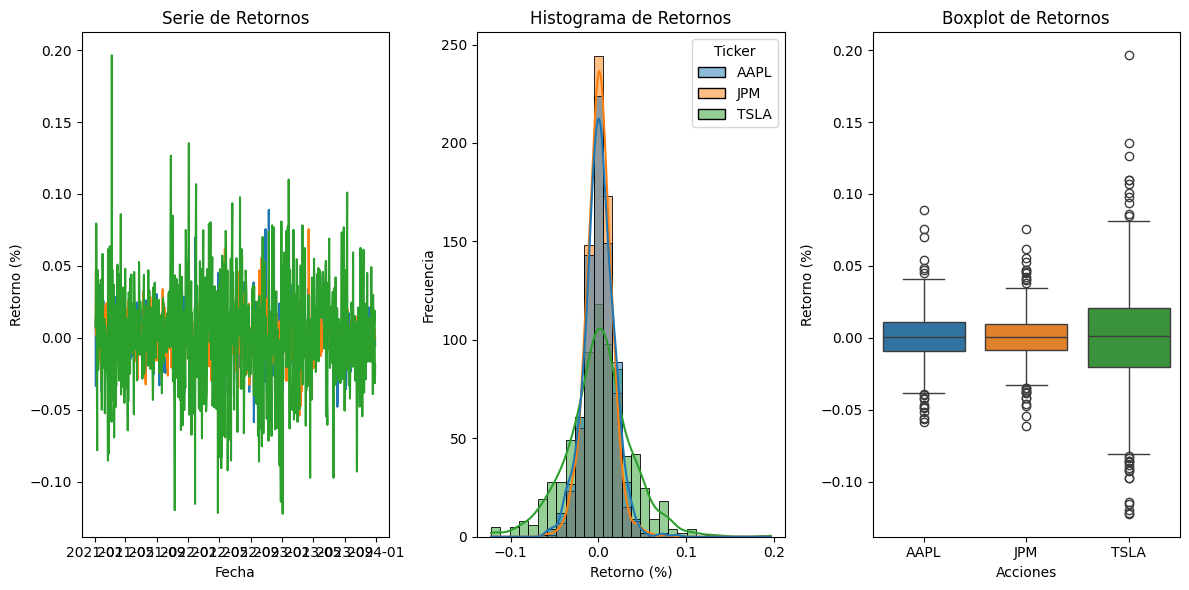

(<Figure size 1200x600 with 3 Axes>,
 array([<Axes: title={'center': 'Serie de Retornos'}, xlabel='Fecha', ylabel='Retorno (%)'>,
        <Axes: title={'center': 'Histograma de Retornos'}, xlabel='Retorno (%)', ylabel='Frecuencia'>,
        <Axes: title={'center': 'Boxplot de Retornos'}, xlabel='Acciones', ylabel='Retorno (%)'>],
       dtype=object))

In [28]:
def plot_retornos(df):
    fig, axes = plt.subplots(1,3, figsize=(12, 6))
    
    #Primer gráfico: Serie de Tiempo
    axes[0].plot(df)
    axes[0].set_title("Serie de Retornos")
    axes[0].set_xlabel("Fecha")
    axes[0].set_ylabel("Retorno (%)")

    #Segundo gráfico: Histograma
    sns.histplot(df, bins=30, kde=True, ax=axes[1])
    axes[1].set_title("Histograma de Retornos")
    axes[1].set_xlabel("Retorno (%)")
    axes[1].set_ylabel("Frecuencia")

    #Tercer gráfico: Boxplot
    sns.boxplot(df, orient='v', ax=axes[2])
    axes[2].set_title("Boxplot de Retornos")
    axes[2].set_xlabel("Acciones")
    axes[2].set_ylabel("Retorno (%)")
    
    plt.tight_layout()
    plt.show()
    return fig, axes

plot_retornos(df_retornos)

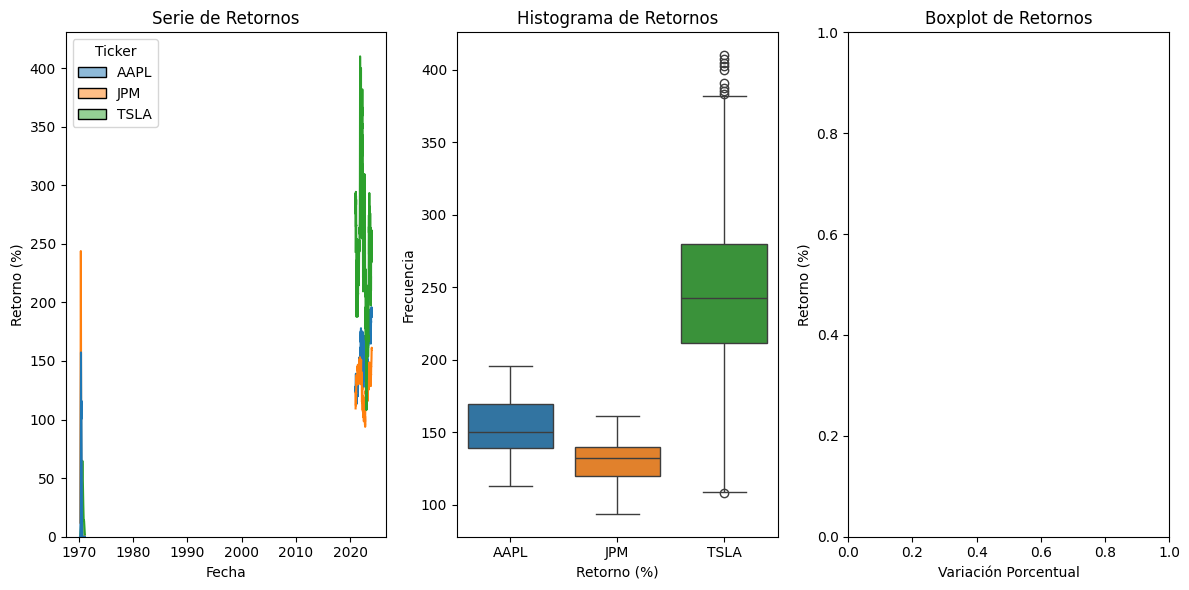

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(12, 6))
    
axes[0].plot(df)
axes[0].set_title("Serie de Retornos")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Retorno (%)")

sns.histplot(df, bins=30, kde=True, ax=axes[0])
axes[1].set_title("Histograma de Retornos")
axes[1].set_xlabel("Retorno (%)")
axes[1].set_ylabel("Frecuencia")

sns.boxplot(df, orient='v', ax=axes[1])
axes[2].set_title("Boxplot de Retornos")
axes[2].set_xlabel("Variación Porcentual")
axes[2].set_ylabel("Retorno (%)")
    
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

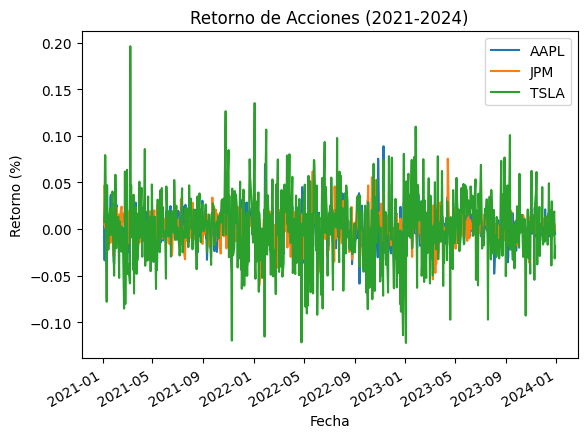

In [12]:
plt.figure(figsize=(10, 6))
df_retornos.plot()
plt.title('Retorno de Acciones (2021-2024)')
plt.xlabel('Fecha')
plt.ylabel('Retorno (%)')
plt.legend(tickers)
plt.show()

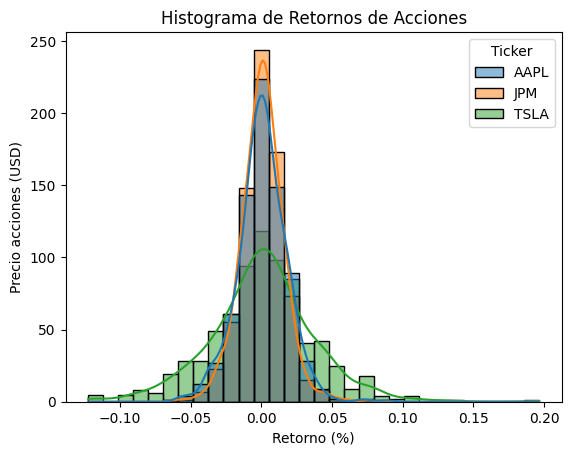

In [13]:
sns.histplot(df_retornos, bins = 30, kde = True)
plt.title("Histograma de Retornos de Acciones")
plt.xlabel("Retorno (%)")
plt.ylabel("Precio acciones (USD)")
plt.show()

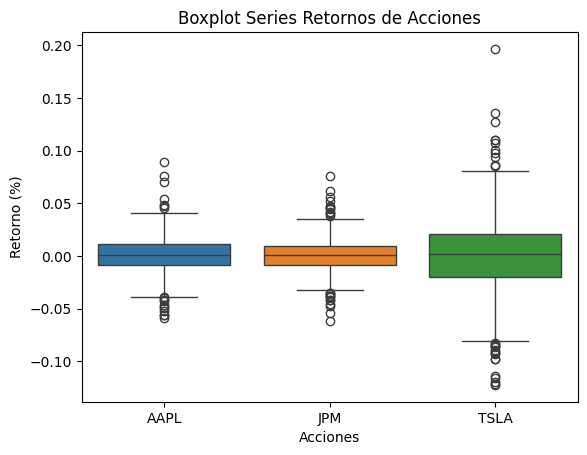

In [21]:
sns.boxplot(df_retornos, orient = 'v')
plt.title("Boxplot Series Retornos de Acciones")
plt.xlabel("Acciones")
plt.ylabel("Retorno (%)")
plt.show()